In [28]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
import os

api_key = os.getenv("GOOGLE_API_KEY")

if os.environ['GOOGLE_API_KEY']:
    print("Google api key is set")
else:
    raise ValueError("Gemini API key is not set")


llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", google_api_key=api_key, temperature=0.7)

Google api key is set


In [ ]:
from typing import TypedDict, List, Annotated, Literal
from langgraph.graph.message import add_messages, BaseMessage
from langchain_core.documents import Document
from langchain_core.messages import ToolMessage
from pydantic import BaseModel, Field

class support_schema(BaseModel):
    question: str
    customerID: str | None = Field(
        default=None,
        description="Customer ID"
    )
    orderID: str | None = Field(
        default=None,
        description="Order ID"
    )
    exists: Literal["Yes", "No"]
    item_list: list

class llm_schema(BaseModel):
    type: Literal["Cancellation", "Refund", "Return", "Warranty", "Shipping"]
    question: str = Field(description="Reframed sentence into which type of poilcy(Cancellation, Refund, Return, Warranty, shipping) should be check for eligibility")
    product_info: str = Field(description="Product name, product buying date(in dd/mm/yyy format), product/order id etc")
    eligibility: Literal["Eligible", "Not Eligible"]
    answer: str

class graph_schema(TypedDict):
    query: str
    document: List[Document]
    product_info: str
    policy_question: str
    eligibility: Literal["Eligible", "Not Eligible"]
    item_list: list
    conversation: Annotated[List[BaseMessage], add_messages]
    answer: str


In [30]:
llm_with_schema = llm.with_structured_output(llm_schema)
llm_with_support_schema = llm.with_structured_output(support_schema)



In [31]:
from langchain_core.tools import tool

@tool
def retriever_embedding_tool():
    """
    Retrieve relevant information from a specific local document.
    
    Use this tool when the user asks a question about a PDF, DOCX,
    TXT, Markdown file, or other provided document.
    
    Args:
        question: The exact question to answer using the document.
        path: The complete filesystem path to the document.
        web_link : Link that will be used to fecth information
    """

In [32]:
tools = []

llm_with_tools = llm.bind_tools(tools)

In [33]:
def get_order_item(id) -> graph_schema:
    orderData = order.fetch_order_by_id(id)
    
    if len(orderData) == 0:
        return {
            "answer": "I couldn't find an order with that order ID.",
        }
            
    items = order_item.fetch_order_items_by_id(id)
    if len(items) == 1:
        return {
            "item_list": items
        }

    item_list = [
        {
            "item_id": i[0],
            "item_name": i[2],
            "item_category": i[3],
            "item_price": i[5]
        }
        for i in items
    ]
    
    return {
        "answer": "Multiple items found in your order specify which one or all?",
        "item_list": item_list
    }

In [34]:
from langchain_core.prompts import ChatPromptTemplate
import os
from RagIntegration import RagRetriever
from DB_Manager.customerDB import CustomerDatabaseManager
from DB_Manager.orderDB import OrderDatabaseManager
from DB_Manager.orderItemsDB import OrderItemDatabaseManager

retriever = RagRetriever()
customer = CustomerDatabaseManager()
order = OrderDatabaseManager()
order_item = OrderItemDatabaseManager()

def track_db_node(state: graph_schema) -> graph_schema:
    user_query = state["conversation"]
    result = llm_with_support_schema.invoke(user_query)
    print(result)


    if result.item_list:
        print(f"Your selected Item{result.item_list}")
        print(f"All Items{state['item_list']}")

    elif result.orderID:
        return get_order_item(result.orderID)
        
    
    elif result.customerID:
        orderData = order.fetch_order_by_customer_id(result.customerID)
        if len(orderData) == 0:
            return {
                "answer": "You don't have any orders",
            }
        
        elif len(orderData) > 1:
            return {
                "answer": "You have multiple orders provide order id"
            }
        else:
            return get_order_item(orderData[0].orderID)

    
    else:
        return {
            "answer": "Please provide your order ID or customer ID."
        }
    
def decision_node(state: graph_schema) -> str:
    answer = state['answer']

    if answer:
        return "end"
    else:
        return "retriever_node"


def retriever_node(state:graph_schema) -> graph_schema:

    query = state["query"]
    result = llm_with_schema.invoke(query)

    policy_dir = "Policies"

    policy_files = {
        "Return": "RETURN_POLICY.pdf",
        "Cancellation": "CANCELLATION_POLICY.pdf",
        "Refund": "REFUND_POLICY.pdf",
        "Warranty": "WARRANTY_POLICY.pdf",
        "Shipping": "SHIPPING_POLICY.pdf",
        "Payment": "PAYMENT_FAQ.pdf"
    }

    file_path = os.path.join(
        policy_dir,
        policy_files[result.type]
    )

    print("Loading:", file_path)
    print("Exists:", os.path.exists(file_path))

    retriever.file_loader(file_path)
    retriever.text_splitting()
    response = retriever.vector_embedding(result.question)

    return {
        "policy_question": result.question,
        "document": response,
        "product_info": result.product_info
    }

def generator_node(state: graph_schema) -> graph_schema:
    user_query = state["query"]
    document = state["document"]
    question = state["policy_question"]
    product_info = state["product_info"]

    context = "\n\n".join(docs.page_content for docs in document)

    prompt = ChatPromptTemplate.from_messages([
    ("system", """
        You are a customer support assistant for an e-commerce company.

        Your task is to answer the user's original question using:
        1. The retrieved company policy as the authoritative source for policy rules.
        2. The customer's product/order information when determining eligibility.
        3. The original user question to understand what the customer wants.

        Instructions:
        - Use the retrieved policy as the source of truth for company rules.
        - Use the product/order information only for facts about the customer's specific product or order.
        - Compare the customer's product/order information against the requirements in the policy when determining eligibility.
        - Do not invent policy rules, customer information, order information, dates, prices, or eligibility conditions.
        - If the policy does not provide enough information to determine eligibility, clearly state that you cannot determine eligibility from the available information.
        - If the customer's product/order information is missing, ask the customer for the required information.
        - If the customer is eligible, clearly explain why based on the policy.
        - If the customer is not eligible, clearly explain which policy requirement is not satisfied.
        - Answer the original user's question, not merely the reframed policy question.
        - Also return eligibility if eligible or not
        - Keep the response clear and direct.
        - Do not mention the RAG system, retrieval process, embeddings, vector database, or internal tools.

        Retrieved Policy Context:
        {context}

        Customer/Product Information:
        {product_info}

        Policy_question:
        {question}
    """),

    ("user", """
        Original Customer Question:
        {user_query}
    """)
])

    chain = prompt | llm_with_schema

    result = chain.invoke({"context": context, "product_info": product_info, "question": question, "user_query": user_query})
    
    return {
        "answer": result.answer,
        "eligibility": result.eligibility
    }


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3766.23it/s]


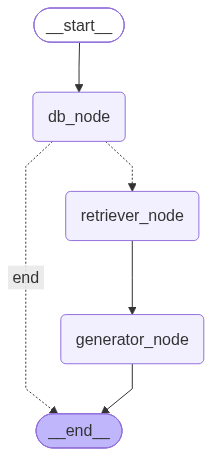

In [35]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("retriever_node", retriever_node)
graph.add_node("db_node", track_db_node)
graph.add_node("generator_node", generator_node)

graph.add_edge(START, "db_node")
graph.add_conditional_edges("db_node", decision_node, {"retriever_node": "retriever_node", "end": END})
graph.add_edge("retriever_node", "generator_node")
graph.add_edge("generator_node", END)

customer_support_agent = graph.compile()

customer_support_agent

In [36]:
from langchain_core.messages import HumanMessage, AIMessage

#ORDTHCG

conversation = []
while True:
    user_query = input("Enter your query (stop to end)...")
    if user_query.lower() == "stop":
        print("Execution Stopped...")
        break

    conversation.append(HumanMessage(content=user_query))

    response = customer_support_agent.invoke({
    "query": user_query,
    "document": [],
    "policy_question":"",
    "product_info": "",
    "eligible": "",
    "answer": "",
    "conversation": conversation,
    "item_list": []
})

    print(response['answer'])
    if response['item_list']:
        print(f"Items:")

        for index, item in enumerate(response["item_list"], start=1):
            print(f"Id: {item['item_id']}")
            print(f"item name: {item['item_name']}")
            print(f"   Category: {item['item_category']}")
            print(f"   Price: ₹{item['item_price']:,.2f}")
            print()

        print("Specify atleast id and name")

    conversation.append(AIMessage(content=response['answer']))

question='i want to return my order of id ORDTHCG' customerID=None orderID='ORDTHCG' exists='Yes' item_list=[]
Multiple items found in your order specify which one or all?
Items:
Id: 1
item name: Dell Inspiron 15
   Category: Laptop
   Price: ₹50,000.00

Id: 2
item name: Logitech Wireless Mouse
   Category: Accessories
   Price: ₹1,000.00

Id: 3
item name: HP Wireless Keyboard
   Category: Accessories
   Price: ₹2,000.00

Specify atleast id and name
question='I want to return my Laptop Dell Inspiron 15 from order ORDTHCG' customerID=None orderID='ORDTHCG' exists='Yes' item_list=['Laptop Dell Inspiron 15']
Your selected Item['Laptop Dell Inspiron 15']
All Items[]
Loading: Policies\WARRANTY_POLICY.pdf
Exists: True
I cannot determine your eligibility for warranty coverage at this time. While your Dell Inspiron 15 is a laptop, which typically carries a 12-month warranty from the date of delivery, I do not have access to your delivery date to confirm if the warranty period is still active. 